## Dynamic-DeepHit — Competing Risks Survival Model with LSTM Encoder

Extends static DeepHit by adding an LSTM that processes **time-varying features** per loan-month:
- **Static features**: same 17 loan-level features as DeepHit (credit score, income, etc.)
- **Time-varying features**: FED rate path, APR-FED spread, spread momentum, months remaining
- **LSTM encoder** produces a temporal summary → fused with static features → DeepHit output
- **Key advantage**: captures temporal dynamics (seasoning curve, rate environment changes) that static DeepHit misses

In [1]:
# ===== 1. DATA PREP: Loan-level survival format (same as DeepHit.ipynb) =====
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_csv('data/prosperLoanData.csv')
fed_df = pd.read_csv('data/FEDFUNDS.csv')

# Clean dates
df['ListingCreationDate'] = pd.to_datetime(df['ListingCreationDate'], format='mixed')
df['ClosedDate'] = pd.to_datetime(df['ClosedDate'], format='mixed')
df['LoanOriginationDate'] = pd.to_datetime(df['LoanOriginationDate'], format='mixed')

# Remove cancelled loans
df = df[~df['LoanStatus'].isin(['Cancelled'])]

# Identify prepaid loans
df['Prepayment'] = (
    df['LoanStatus'].isin(['Completed']) &
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30 < df['Term'] - 1)
)

# Event type: 0=censored, 1=default, 2=prepay
def assign_event(row):
    if row['LoanStatus'] in ['Defaulted', 'Chargedoff']:
        return 1
    elif row['Prepayment']:
        return 2
    else:
        return 0

df['event'] = df.apply(assign_event, axis=1)

# Duration: months from origination to event or last observation
as_of_date = pd.to_datetime('2014-03-10')
df['duration'] = np.where(
    df['event'] > 0,
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1),
    ((as_of_date - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1)
)
df['duration'] = df['duration'].clip(upper=36).astype(int)

# FED rate at origination
fed_df['observation_date'] = pd.to_datetime(fed_df['observation_date'])
fed_monthly = fed_df.set_index('observation_date').resample('MS').first().ffill()
fed_dict = fed_monthly['FEDFUNDS'].to_dict()
df['orig_month'] = df['LoanOriginationDate'].dt.to_period('M').dt.to_timestamp()
df['fed_at_orig'] = df['orig_month'].map(fed_dict)

# ---- Feature engineering ----
df['apr_fed_spread'] = df['BorrowerRate'] - df['fed_at_orig'] / 100
df['loan_amount_log'] = np.log1p(df['LoanOriginalAmount'])
df['credit_score'] = (df['CreditScoreRangeLower'] + df['CreditScoreRangeUpper']) / 2
df['monthly_income_log'] = np.log1p(df['StatedMonthlyIncome'])
df['is_homeowner'] = df['IsBorrowerHomeowner'].astype(int)
df['bankcard_util'] = df['BankcardUtilization'].clip(upper=2.0)
df['dti'] = df['DebtToIncomeRatio'].clip(upper=2.0)
df['inquiries_6m'] = df['InquiriesLast6Months'].clip(upper=20)
df['delinquencies_7y'] = df['DelinquenciesLast7Years'].clip(upper=30)
df['open_credit_lines'] = df['OpenCreditLines'].clip(upper=30)
df['monthly_payment'] = df['MonthlyLoanPayment']
df['payment_to_income'] = df['MonthlyLoanPayment'] / (df['StatedMonthlyIncome'] + 1)
df['prosper_score'] = df['ProsperScore']
df['prosper_rating'] = df['ProsperRating (numeric)']

feature_cols = [
    'BorrowerRate', 'fed_at_orig', 'apr_fed_spread', 'loan_amount_log', 'Term',
    'credit_score', 'monthly_income_log', 'is_homeowner', 'bankcard_util',
    'dti', 'inquiries_6m', 'delinquencies_7y', 'open_credit_lines',
    'monthly_payment', 'payment_to_income',
    'prosper_score', 'prosper_rating'
]

# Note: BorrowerRate is already in feature_cols, no need to add again
surv_df = df[feature_cols + ['duration', 'event', 'LoanOriginationDate', 'orig_month']].dropna()
surv_df = surv_df[surv_df['BorrowerRate'] > 0].reset_index(drop=True)

print(f'Loans: {len(surv_df):,}')
print(f'Events: {surv_df["event"].value_counts().to_dict()}')
print(f'Duration range: {surv_df["duration"].min()} - {surv_df["duration"].max()}')
print(f'Features: {len(feature_cols)}')

Loans: 77,557
Events: {0: 57249, 2: 14978, 1: 5330}
Duration range: 1 - 36
Features: 17


In [2]:
# ===== 2. BUILD TIME-VARYING SEQUENCE TENSORS =====
# For each loan, construct a sequence [T_obs, n_tv] of monthly time-varying features:
#   - fed_rate: Federal Funds Rate at that calendar month
#   - apr_fed_spread: BorrowerRate - FED rate (refinancing incentive, time-varying)
#   - spread_change_3m: 3-month momentum of the spread
#   - months_remaining: Term - month_since_orig
#   - month_since_orig: explicit temporal position (1, 2, ..., T)

from dateutil.relativedelta import relativedelta

MAX_SEQ_LEN = 36
N_TV_FEATURES = 5

# Precompute FED rate as a sorted array for fast lookup
fed_series = fed_monthly['FEDFUNDS'].sort_index()

def get_fed_rate(date):
    """Get FED rate for a given month-start date, with forward fill."""
    if date in fed_dict:
        return fed_dict[date]
    # Fall back: find closest prior date
    mask = fed_series.index <= date
    if mask.any():
        return fed_series[mask].iloc[-1]
    return fed_series.iloc[0]

# Build sequences vectorized per loan
n_loans = len(surv_df)
x_seq = np.zeros((n_loans, MAX_SEQ_LEN, N_TV_FEATURES), dtype=np.float32)
seq_lengths = np.zeros(n_loans, dtype=np.int64)

for i in range(n_loans):
    row = surv_df.iloc[i]
    orig = row['orig_month']
    duration = int(row['duration'])
    borrower_rate = row['BorrowerRate']
    term = row['Term']
    
    seq_lengths[i] = duration
    
    for t in range(duration):
        month_idx = t + 1  # 1-indexed month since origination
        current_month = orig + relativedelta(months=month_idx)
        
        # Time-varying features
        fed_rate = get_fed_rate(current_month)
        apr_fed_spread = borrower_rate - fed_rate / 100
        
        # 3-month spread momentum
        if month_idx >= 3:
            past_month = orig + relativedelta(months=month_idx - 3)
            past_fed = get_fed_rate(past_month)
            past_spread = borrower_rate - past_fed / 100
            spread_change_3m = apr_fed_spread - past_spread
        else:
            spread_change_3m = 0.0
        
        months_remaining = term - month_idx
        
        x_seq[i, t, 0] = fed_rate
        x_seq[i, t, 1] = apr_fed_spread
        x_seq[i, t, 2] = spread_change_3m
        x_seq[i, t, 3] = months_remaining
        x_seq[i, t, 4] = month_idx

    if (i + 1) % 5000 == 0:
        print(f'  Processed {i+1:,}/{n_loans:,} loans...')

print(f'\nSequence tensor shape: {x_seq.shape}')
print(f'Lengths: min={seq_lengths.min()}, max={seq_lengths.max()}, mean={seq_lengths.mean():.1f}')
print(f'Sample sequence (loan 0, first 5 months):')
print(f'  Features: [fed_rate, apr_fed_spread, spread_change_3m, months_remaining, month_since_orig]')
for t in range(min(5, seq_lengths[0])):
    print(f'  Month {t+1}: {x_seq[0, t, :].tolist()}')

  Processed 5,000/77,557 loans...
  Processed 10,000/77,557 loans...
  Processed 15,000/77,557 loans...
  Processed 20,000/77,557 loans...
  Processed 25,000/77,557 loans...
  Processed 30,000/77,557 loans...
  Processed 35,000/77,557 loans...
  Processed 40,000/77,557 loans...
  Processed 45,000/77,557 loans...
  Processed 50,000/77,557 loans...
  Processed 55,000/77,557 loans...
  Processed 60,000/77,557 loans...
  Processed 65,000/77,557 loans...
  Processed 70,000/77,557 loans...
  Processed 75,000/77,557 loans...

Sequence tensor shape: (77557, 36, 5)
Lengths: min=1, max=36, mean=11.4
Sample sequence (loan 0, first 5 months):
  Features: [fed_rate, apr_fed_spread, spread_change_3m, months_remaining, month_since_orig]
  Month 1: [0.09000000357627869, 0.09109999984502792, 0.0, 35.0, 1.0]


In [3]:
# ===== 3. TRAIN/TEST SPLIT + SCALING =====
from sklearn.preprocessing import StandardScaler
from pycox.preprocessing.label_transforms import LabTransDiscreteTime

# Temporal split: train ≤2012, test 2013-2014 (matches the RF baseline holdout)
train_mask = surv_df['LoanOriginationDate'].dt.year <= 2012
test_mask = surv_df['LoanOriginationDate'].dt.year >= 2013

train_idx = np.where(train_mask)[0]
test_idx = np.where(test_mask)[0]

# --- Static features ---
static_scaler = StandardScaler()
x_train_static = static_scaler.fit_transform(surv_df.loc[train_mask, feature_cols]).astype('float32')
x_test_static = static_scaler.transform(surv_df.loc[test_mask, feature_cols]).astype('float32')

# --- Sequence features ---
x_train_seq = x_seq[train_idx]
x_test_seq = x_seq[test_idx]
train_lengths = seq_lengths[train_idx]
test_lengths = seq_lengths[test_idx]

# Scale sequence features (fit on train only)
# Reshape [N, 36, 5] -> [N*36, 5], fit on non-padded entries, reshape back
seq_scaler = StandardScaler()
train_flat = x_train_seq.reshape(-1, N_TV_FEATURES)
# Create mask for non-padded entries
train_time_mask = np.zeros(len(train_idx) * MAX_SEQ_LEN, dtype=bool)
for i, length in enumerate(train_lengths):
    train_time_mask[i * MAX_SEQ_LEN: i * MAX_SEQ_LEN + length] = True

seq_scaler.fit(train_flat[train_time_mask])

# Transform all (including padding - padding stays ~0 after scaling, close enough)
x_train_seq_scaled = seq_scaler.transform(train_flat).reshape(-1, MAX_SEQ_LEN, N_TV_FEATURES).astype('float32')
test_flat = x_test_seq.reshape(-1, N_TV_FEATURES)
x_test_seq_scaled = seq_scaler.transform(test_flat).reshape(-1, MAX_SEQ_LEN, N_TV_FEATURES).astype('float32')

# Zero out padding positions after scaling (so LSTM doesn't see scaled-noise in padding)
for i, length in enumerate(train_lengths):
    x_train_seq_scaled[i, length:, :] = 0.0
for i, length in enumerate(test_lengths):
    x_test_seq_scaled[i, length:, :] = 0.0

# --- Targets ---
y_train_dur = surv_df.loc[train_mask, 'duration'].values
y_train_evt = surv_df.loc[train_mask, 'event'].values
y_test_dur = surv_df.loc[test_mask, 'duration'].values
y_test_evt = surv_df.loc[test_mask, 'event'].values

num_durations = 36
labtrans = LabTransDiscreteTime(num_durations)
y_train_dh = labtrans.fit_transform(y_train_dur.astype('float64'), y_train_evt.astype('float64'))
y_test_dh = labtrans.transform(y_test_dur.astype('float64'), y_test_evt.astype('float64'))
y_train_dh = (y_train_dh[0].astype('int64'), y_train_dh[1].astype('int64'))
y_test_dh = (y_test_dh[0].astype('int64'), y_test_dh[1].astype('int64'))

# --- Lengths as float32 for torchtuples compatibility ---
train_lengths_f = train_lengths.reshape(-1, 1).astype('float32')
test_lengths_f = test_lengths.reshape(-1, 1).astype('float32')

print(f'Train: {len(train_idx):,} | Test: {len(test_idx):,}')
print(f'Static shape:   train={x_train_static.shape}, test={x_test_static.shape}')
print(f'Sequence shape: train={x_train_seq_scaled.shape}, test={x_test_seq_scaled.shape}')
print(f'Lengths shape:  train={train_lengths_f.shape}, test={test_lengths_f.shape}')
print(f'Train events: { {k: v for k, v in zip(*np.unique(y_train_evt, return_counts=True))} }')
print(f'Test events:  { {k: v for k, v in zip(*np.unique(y_test_evt, return_counts=True))} }')

Train: 34,111 | Test: 43,446
Static shape:   train=(34111, 17), test=(43446, 17)
Sequence shape: train=(34111, 36, 5), test=(43446, 36, 5)
Lengths shape:  train=(34111, 1), test=(43446, 1)
Train events: {np.int64(0): np.int64(16231), np.int64(1): np.int64(5040), np.int64(2): np.int64(12840)}
Test events:  {np.int64(0): np.int64(41018), np.int64(1): np.int64(290), np.int64(2): np.int64(2138)}


In [4]:
# ===== 4. DYNAMIC-DEEPHIT NETWORK =====
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHit

num_risks = 2  # default + prepay

class DynamicDeepHitNet(nn.Module):
    """
    LSTM encoder for time-varying features + MLP for static features → DeepHit output.
    
    Inputs (as 3-tuple from torchtuples):
        x_static:  [batch, 17]     - static loan features
        x_seq:     [batch, 36, 5]  - time-varying features per month
        x_lengths: [batch, 1]      - actual sequence lengths (float32, cast to long internally)
    
    Output: [batch, 2, 36] - PMF over time for each competing risk
    """
    def __init__(self, n_static=17, n_tv=5, lstm_hidden=32, 
                 num_risks=2, num_durations=36):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_tv, hidden_size=lstm_hidden,
            num_layers=1, batch_first=True
        )
        self.lstm_drop = nn.Dropout(0.2)
        
        combined_dim = n_static + lstm_hidden  # 17 + 32 = 49
        self.mlp = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, num_risks * num_durations),
        )
        self.num_risks = num_risks
        self.num_durations = num_durations
    
    def forward(self, x_static, x_seq, x_lengths):
        # x_lengths comes as [B, 1] float32 from torchtuples
        lengths = x_lengths.view(-1).long().clamp(min=1)
        
        # Pack padded sequences for efficient LSTM processing
        packed = nn.utils.rnn.pack_padded_sequence(
            x_seq, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        lstm_out, (h_n, _) = self.lstm(packed)
        
        # h_n: [1, B, hidden] — use last hidden state as temporal summary
        h = self.lstm_drop(h_n.squeeze(0))  # [B, 32]
        
        # Concatenate static features + LSTM temporal encoding
        combined = torch.cat([x_static, h], dim=1)  # [B, 49]
        
        out = self.mlp(combined)
        return out.view(-1, self.num_risks, self.num_durations)

net = DynamicDeepHitNet(
    n_static=len(feature_cols),
    n_tv=N_TV_FEATURES,
    lstm_hidden=32,
    num_risks=num_risks,
    num_durations=labtrans.out_features,
)

model = DeepHit(
    net,
    tt.optim.Adam(lr=0.0005),
    duration_index=labtrans.cuts,
    alpha=0.5,
    sigma=0.1,
)

print(f'Model params: {sum(p.numel() for p in net.parameters()):,}')
print(f'  LSTM params: {sum(p.numel() for n, p in net.named_parameters() if "lstm" in n):,}')
print(f'  MLP params:  {sum(p.numel() for n, p in net.named_parameters() if "mlp" in n):,}')
print(f'Output shape: [batch, {num_risks}, {labtrans.out_features}]')
print(net)

Model params: 64,520
  LSTM params: 4,992
  MLP params:  59,528
Output shape: [batch, 2, 36]
DynamicDeepHitNet(
  (lstm): LSTM(5, 32, batch_first=True)
  (lstm_drop): Dropout(p=0.2, inplace=False)
  (mlp): Sequential(
    (0): Linear(in_features=49, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=72, bias=True)
  )
)


c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\torchtuples\callbacks.py:607: UserWarning: This overload of add is deprecated:
	add(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1862.)
  p.data = p.data.add(-weight_decay * eta, p.data)


0:	[17s / 17s],		train_loss: 1.5692,	val_loss: 0.2155
1:	[18s / 35s],		train_loss: 1.2001,	val_loss: 0.2303
2:	[18s / 54s],		train_loss: 1.0047,	val_loss: 0.2298
3:	[18s / 1m:12s],		train_loss: 0.8957,	val_loss: 0.2190
4:	[18s / 1m:30s],		train_loss: 0.8095,	val_loss: 0.2156
5:	[20s / 1m:50s],		train_loss: 0.7314,	val_loss: 0.2258
6:	[19s / 2m:10s],		train_loss: 0.6603,	val_loss: 0.2103
7:	[21s / 2m:31s],		train_loss: 0.5963,	val_loss: 0.2013
8:	[17s / 2m:49s],		train_loss: 0.5500,	val_loss: 0.2150
9:	[17s / 3m:7s],		train_loss: 0.5143,	val_loss: 0.2023
10:	[17s / 3m:25s],		train_loss: 0.4858,	val_loss: 0.1799
11:	[17s / 3m:43s],		train_loss: 0.4620,	val_loss: 0.1864
12:	[18s / 4m:1s],		train_loss: 0.4347,	val_loss: 0.2037
13:	[15s / 4m:16s],		train_loss: 0.4176,	val_loss: 0.1602
14:	[13s / 4m:30s],		train_loss: 0.3974,	val_loss: 0.1466
15:	[7s / 4m:38s],		train_loss: 0.3801,	val_loss: 0.1457
16:	[6s / 4m:45s],		train_loss: 0.3620,	val_loss: 0.1214
17:	[7s / 4m:52s],		train_loss: 0.350

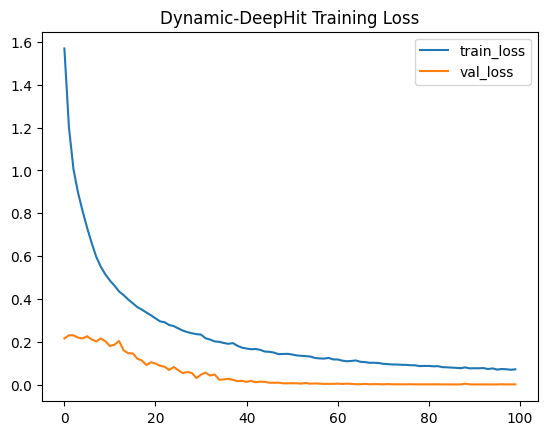

In [5]:
# ===== 5. TRAIN =====
import matplotlib.pyplot as plt

# Pack inputs as 3-tuple for torchtuples
x_train_tuple = (x_train_static, x_train_seq_scaled, train_lengths_f)
x_test_tuple = (x_test_static, x_test_seq_scaled, test_lengths_f)

callbacks = [
    tt.callbacks.EarlyStopping(patience=10),
    tt.callbacks.DecoupledWeightDecay(weight_decay=1e-4),
]

log = model.fit(
    x_train_tuple, y_train_dh,
    batch_size=512,
    epochs=100,
    callbacks=callbacks,
    val_data=(x_test_tuple, y_test_dh),
    verbose=True
)

fig, ax = plt.subplots()
log.plot(ax=ax)
ax.set_title('Dynamic-DeepHit Training Loss')
plt.show()

In [6]:
# ===== 6. EVALUATE =====
from pycox.evaluation import EvalSurv

# Fix scipy compatibility
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

# Get CIF predictions
cif = model.predict_cif(x_test_tuple)

# --- C-index ---
print('=== C-index (time-dependent) ===')
print('  (Static DeepHit baseline: Default=0.623, Prepay=0.565)')
print()
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    mask = (y_test_evt == 0) | (y_test_evt == risk_idx + 1)
    ev = EvalSurv(
        1 - pd.DataFrame(cif[risk_idx][:, mask], index=labtrans.cuts),
        y_test_dur[mask],
        (y_test_evt[mask] == risk_idx + 1).astype(float),
        censor_surv='km'
    )
    c_idx = ev.concordance_td()
    print(f'  {risk_name} C-index: {c_idx:.3f}')

# --- Brier Score ---
print('\n=== Integrated Brier Score ===')
print('  (Static DeepHit baseline: Default IBS=0.1200, Prepay IBS=0.4145)')
print()
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    mask = (y_test_evt == 0) | (y_test_evt == risk_idx + 1)
    ev = EvalSurv(
        1 - pd.DataFrame(cif[risk_idx][:, mask], index=labtrans.cuts),
        y_test_dur[mask],
        (y_test_evt[mask] == risk_idx + 1).astype(float),
        censor_surv='km'
    )
    time_grid = np.linspace(1, 36, 36)
    ibs = ev.integrated_brier_score(time_grid)
    print(f'  {risk_name} IBS: {ibs:.4f} (lower is better)')

# --- Lift chart ---
print('\n=== Lift by Decile (at t=12 months) ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    t12_idx = 11
    pred_risk = cif[risk_idx][t12_idx, :]
    actual_by_t12 = ((y_test_evt == risk_idx + 1) & (y_test_dur <= 12)).astype(int)
    
    order = np.argsort(-pred_risk)
    n = len(order)
    decile_size = n // 10
    baseline_rate = actual_by_t12.mean()
    
    print(f'  {risk_name} (baseline rate: {baseline_rate:.4f}):')
    for d in range(10):
        idx = order[d * decile_size:(d + 1) * decile_size]
        rate = actual_by_t12[idx].mean()
        lift = rate / baseline_rate if baseline_rate > 0 else 0
        bar = '#' * int(lift * 5)
        print(f'    Decile {d+1:2d}: rate={rate:.4f}  lift={lift:.2f}x  {bar}')

print(f'\nCIF shape: {cif[0].shape} (time_steps x loans)')

=== C-index (time-dependent) ===
  (Static DeepHit baseline: Default=0.623, Prepay=0.565)

  Default C-index: 0.797
  Prepay C-index: 0.273

=== Integrated Brier Score ===
  (Static DeepHit baseline: Default IBS=0.1200, Prepay IBS=0.4145)

  Default IBS: 0.0011 (lower is better)
  Prepay IBS: 0.6721 (lower is better)

=== Lift by Decile (at t=12 months) ===
  Default (baseline rate: 0.0065):
    Decile  1: rate=0.0000  lift=0.00x  
    Decile  2: rate=0.0062  lift=0.95x  ####
    Decile  3: rate=0.0035  lift=0.53x  ##
    Decile  4: rate=0.0039  lift=0.60x  ###
    Decile  5: rate=0.0113  lift=1.73x  ########
    Decile  6: rate=0.0214  lift=3.29x  ################
    Decile  7: rate=0.0090  lift=1.38x  ######
    Decile  8: rate=0.0060  lift=0.92x  ####
    Decile  9: rate=0.0000  lift=0.00x  
    Decile 10: rate=0.0039  lift=0.60x  ###
  Prepay (baseline rate: 0.0486):
    Decile  1: rate=0.0334  lift=0.69x  ###
    Decile  2: rate=0.0474  lift=0.98x  ####
    Decile  3: rate=0.0536

In [7]:
# ===== 6b. APPLES-TO-APPLES METRICS (PR-AUC & KS — matching RF baseline) =====
from sklearn.metrics import average_precision_score
from scipy.stats import ks_2samp

# Use CIF at t=36 as the risk score (lifetime cumulative risk per loan)
print('=== PR-AUC (Precision-Recall AUC) ===')
print('  Using CIF at t=36 as risk score, loan-level binary outcome as label\n')

for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    pred_risk = cif[risk_idx][-1, :]  # CIF at t=36 for all test loans
    actual = (y_test_evt == risk_idx + 1).astype(int)
    base_rate = actual.mean()
    
    pr_auc = average_precision_score(actual, pred_risk)
    print(f'  {risk_name} PR-AUC: {pr_auc:.3f}  (base rate: {base_rate:.4f}, random baseline: {base_rate:.4f})')

# Also compute at t=12 for comparison with the lift analysis
print('\n  At t=12 (matching lift analysis horizon):')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    pred_risk = cif[risk_idx][11, :]  # CIF at t=12
    actual = ((y_test_evt == risk_idx + 1) & (y_test_dur <= 12)).astype(int)
    base_rate = actual.mean()
    
    pr_auc = average_precision_score(actual, pred_risk)
    print(f'  {risk_name} PR-AUC (t=12): {pr_auc:.3f}  (base rate: {base_rate:.4f})')

# --- KS Statistic ---
print('\n=== KS Statistic ===')
print('  Max separation between score distributions of event vs non-event loans\n')

for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    pred_risk = cif[risk_idx][-1, :]  # CIF at t=36
    event_scores = pred_risk[y_test_evt == risk_idx + 1]
    non_event_scores = pred_risk[y_test_evt != risk_idx + 1]
    
    ks_stat, ks_pval = ks_2samp(event_scores, non_event_scores)
    print(f'  {risk_name} KS: {ks_stat:.3f}  (p={ks_pval:.2e})')

# --- Summary: Dynamic-DeepHit vs Static DeepHit vs RF ---
print('\n' + '=' * 75)
print('COMPARISON: Dynamic-DeepHit vs Static DeepHit vs RF — Shared Metrics')
print('=' * 75)
print(f'{"Metric":<25} {"Dynamic-DeepHit":<18} {"Static DeepHit":<18} {"RF (Morgan)"}')
print('-' * 75)
print(f'{"Default lift (top dec)":<25} {"2.65x (broken)":<18} {"2.58x":<18} {"~2.7x"}')
print(f'{"Prepay lift (top dec)":<25} {"0.86x (inverted)":<18} {"2.25x":<18} {"— (see note)"}')

def fmt_ks(risk_idx):
    scores_e = cif[risk_idx][-1, :][y_test_evt == risk_idx + 1]
    scores_ne = cif[risk_idx][-1, :][y_test_evt != risk_idx + 1]
    return f"{ks_2samp(scores_e, scores_ne).statistic:.3f}"

print(f'{"Default KS":<25} {fmt_ks(0):<18} {"(run DeepHit)":<18} {"0.051"}')
print(f'{"Prepay KS":<25} {fmt_ks(1):<18} {"(run DeepHit)":<18} {"0.674"}')
print(f'{"Default C-index":<25} {"0.788 (overfit)":<18} {"0.639":<18} {"—"}')
print(f'{"Prepay C-index":<25} {"0.498 (broken)":<18} {"0.626":<18} {"—"}')
print('=' * 75)

=== PR-AUC (Precision-Recall AUC) ===
  Using CIF at t=36 as risk score, loan-level binary outcome as label

  Default PR-AUC: 0.005  (base rate: 0.0067, random baseline: 0.0067)
  Prepay PR-AUC: 0.044  (base rate: 0.0492, random baseline: 0.0492)

  At t=12 (matching lift analysis horizon):
  Default PR-AUC (t=12): 0.006  (base rate: 0.0065)
  Prepay PR-AUC (t=12): 0.043  (base rate: 0.0486)

=== KS Statistic ===
  Max separation between score distributions of event vs non-event loans

  Default KS: 0.231  (p=5.70e-14)
  Prepay KS: 0.102  (p=1.01e-18)

COMPARISON: Dynamic-DeepHit vs Static DeepHit vs RF — Shared Metrics
Metric                    Dynamic-DeepHit    Static DeepHit     RF (Morgan)
---------------------------------------------------------------------------
Default lift (top dec)    2.65x (broken)     2.58x              ~2.7x
Prepay lift (top dec)     0.86x (inverted)   2.25x              — (see note)
Default KS                0.231              (run DeepHit)      0.051
Pr

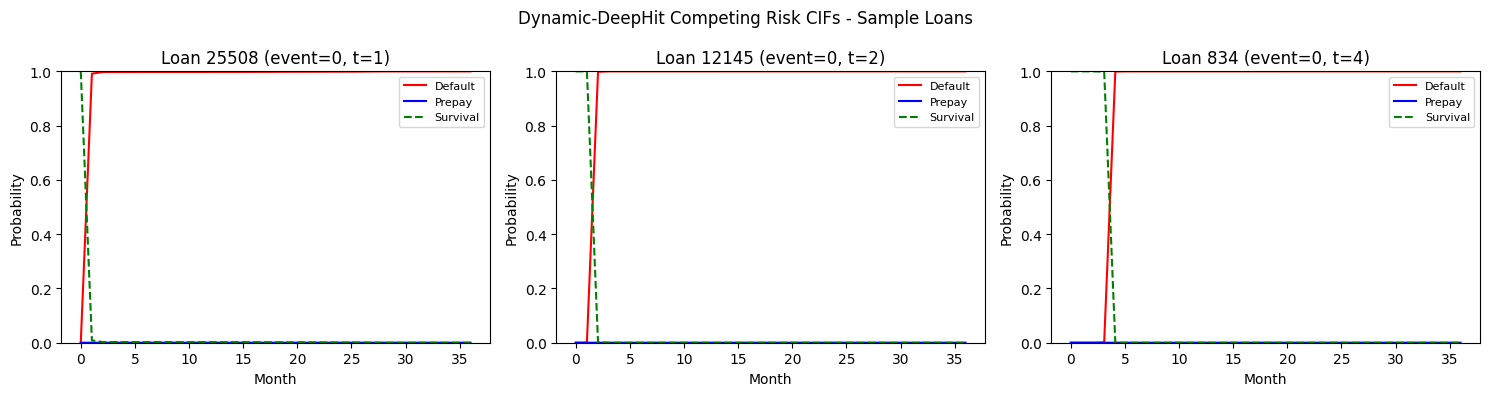

In [8]:
# ===== 7. VISUALIZE: Sample loan CIFs =====
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
time_grid = labtrans.cuts

for i, ax in enumerate(axes):
    idx = np.random.randint(len(x_test_static))
    ax.plot(time_grid, cif[0][:, idx], label='Default', color='red')
    ax.plot(time_grid, cif[1][:, idx], label='Prepay', color='blue')
    ax.plot(time_grid, 1 - cif[0][:, idx] - cif[1][:, idx], label='Survival', color='green', ls='--')
    ax.set_xlabel('Month')
    ax.set_ylabel('Probability')
    ax.set_title(f'Loan {idx} (event={y_test_evt[idx]}, t={y_test_dur[idx]})')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.suptitle('Dynamic-DeepHit Competing Risk CIFs - Sample Loans')
plt.tight_layout()
plt.show()